In [ ]:
%load_ext autoreload
%autoreload 2

import sys
import random
from pathlib import Path

sys.path.append(str(Path.cwd().parent))

import joblib
import numpy as np
import pandas as pd
import torch
from torch.utils.data import DataLoader
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score, 
                             confusion_matrix, roc_curve, roc_auc_score)
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image as PILImage

from src.config import OUTPUTS, IMG_SIZE, MLP_IMG_SIZE, IMAGENET_MEAN, IMAGENET_STD
from src.mlp import MLP, _cargar_split_pca
from src.cnn import CNN
from src.transfer import build_feature_extractor, build_fine_tuner
from src.data import ImageDataset, get_transforms

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


# Evaluación de Modelos - Clasificación Real vs Generado por IA

Comparación de cuatro modelos sobre el test set. Todos fueron entrenados con el mismo split de datos.

| Modelo | Enfoque | Input |
|--------|---------|-------|
| MLP | Lineal sobre componentes PCA | 128x128 $\rightarrow$ PCA (321 componentes) |
| CNN | Convolucional desde cero | 224x224 píxeles |
| Transfer FE | ResNet50 backbone congelado | 224x224 píxeles |
| Transfer FT | ResNet50 layer4 + fc descongelados | 224x224 píxeles |

## 1. MLP

In [26]:
# Cargar PCA y modelo
pca = joblib.load(OUTPUTS / "pca_mlp.joblib")

model = MLP(input_dim=pca.n_components_)
model.load_state_dict(torch.load(OUTPUTS / "mlp_best.pt", map_location="cpu"))
model.eval()

print(f"Componentes PCA: {pca.n_components_}")
print("Modelo cargado.")

Componentes PCA: 321
Modelo cargado.


In [27]:
# Cargar split de test y obtener predicciones
X_test, y_test = _cargar_split_pca("test", pca)

with torch.no_grad():
    logits = model(X_test)
    y_pred = (logits.sigmoid() >= 0.5).int().squeeze().numpy()

y_true = y_test.squeeze().int().numpy()

Cargando test:   0%|          | 0/5997 [00:00<?, ?it/s]

In [28]:
# Métricas
print(f"Accuracy:  {accuracy_score(y_true, y_pred):.4f}")
print(f"Precision: {precision_score(y_true, y_pred):.4f}")
print(f"Recall:    {recall_score(y_true, y_pred):.4f}")
print(f"F1:        {f1_score(y_true, y_pred):.4f}")

Accuracy:  0.7237
Precision: 0.7017
Recall:    0.7787
F1:        0.7382


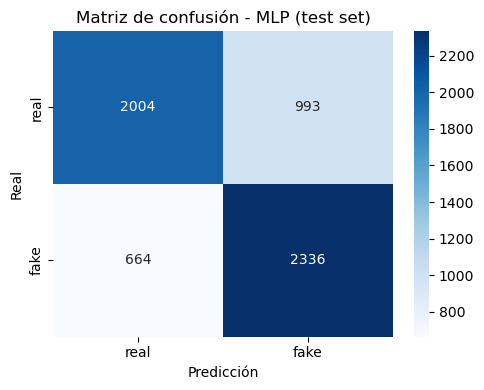

In [29]:
# Matriz de confusión
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=["real", "fake"], yticklabels=["real", "fake"])
plt.xlabel("Predicción")
plt.ylabel("Real")
plt.title("Matriz de confusión - MLP (test set)")
plt.tight_layout()
plt.show()

## 2. CNN

In [30]:
cnn_model = CNN()
cnn_model.load_state_dict(torch.load(OUTPUTS / "cnn_best.pt", map_location="cpu"))
cnn_model.eval()
print("CNN cargada.")

CNN cargada.


In [31]:
test_loader = DataLoader(ImageDataset("test"), batch_size=128, shuffle=False)

all_preds, all_labels = [], []
with torch.no_grad():
    for imgs, labels in test_loader:
        logits = cnn_model(imgs)
        preds  = (logits.sigmoid() >= 0.5).int().squeeze()
        all_preds.append(preds)
        all_labels.append(labels)

y_pred_cnn = torch.cat(all_preds).numpy()
y_true_cnn = torch.cat(all_labels).numpy()

In [32]:
print(f"Accuracy:  {accuracy_score(y_true_cnn, y_pred_cnn):.4f}")
print(f"Precision: {precision_score(y_true_cnn, y_pred_cnn):.4f}")
print(f"Recall:    {recall_score(y_true_cnn, y_pred_cnn):.4f}")
print(f"F1:        {f1_score(y_true_cnn, y_pred_cnn):.4f}")

Accuracy:  0.8843
Precision: 0.9037
Recall:    0.8603
F1:        0.8815


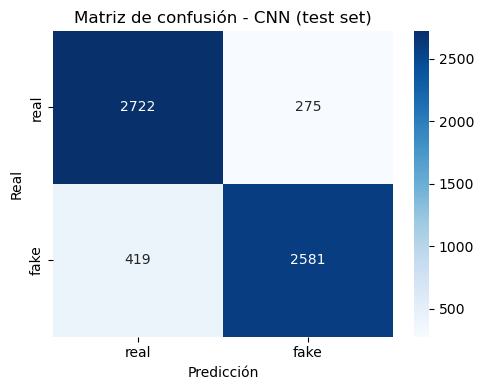

In [33]:
cm_cnn = confusion_matrix(y_true_cnn, y_pred_cnn)

plt.figure(figsize=(5, 4))
sns.heatmap(cm_cnn, annot=True, fmt="d", cmap="Blues", xticklabels=["real", "fake"], yticklabels=["real", "fake"])
plt.xlabel("Predicción")
plt.ylabel("Real")
plt.title("Matriz de confusión - CNN (test set)")
plt.tight_layout()
plt.show()

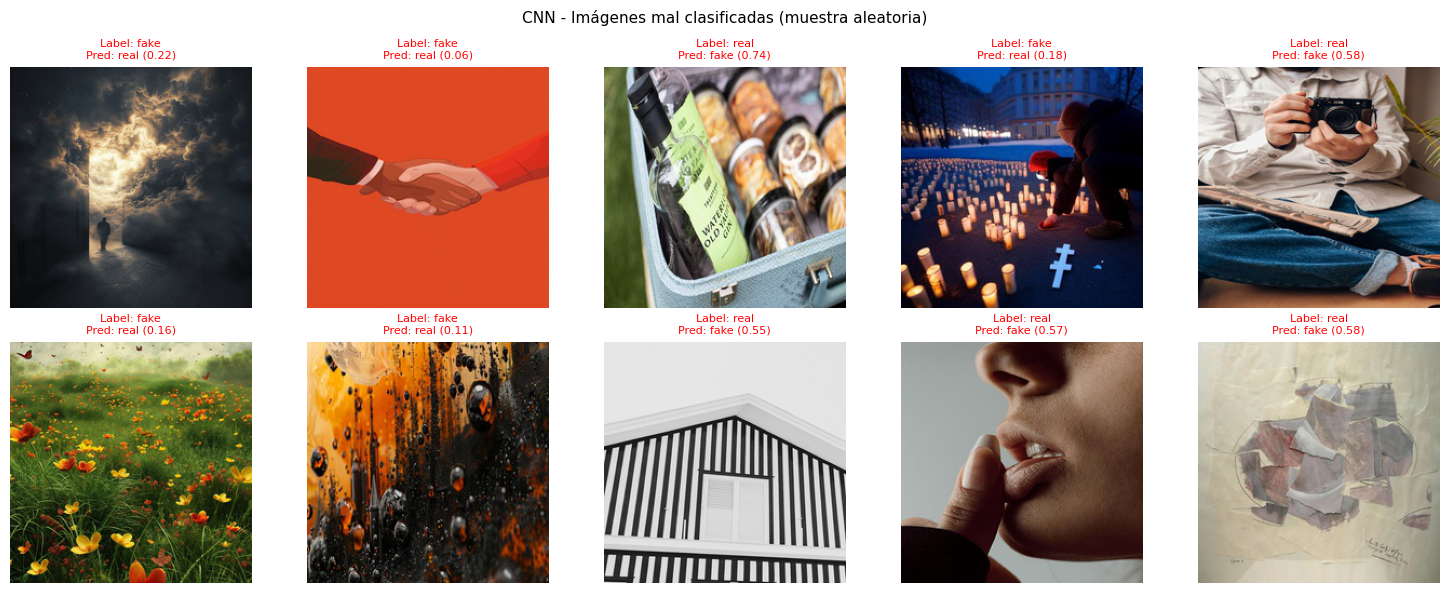

In [34]:
n = 10
dataset = ImageDataset("test")
INT_TO_LABEL = {0: "real", 1: "fake"}

mean = torch.tensor(IMAGENET_MEAN).view(3, 1, 1)
std = torch.tensor(IMAGENET_STD).view(3, 1, 1)

errores = []
cnn_model.eval()
with torch.no_grad():
    for idx in random.sample(range(len(dataset)), len(dataset)):
        if len(errores) == n:
            break
        img_tensor, label_int = dataset[idx]
        prob = cnn_model(img_tensor.unsqueeze(0)).sigmoid().item()
        pred = "fake" if prob >= 0.5 else "real"
        real = INT_TO_LABEL[label_int]
        if pred != real:
            errores.append((img_tensor, real, pred, prob))

fig, axes = plt.subplots(2, 5, figsize=(15, 6))
axes = axes.flatten()

for i, (img_tensor, real, pred, prob) in enumerate(errores):
    img_np = (img_tensor * std + mean).permute(1, 2, 0).clamp(0, 1).numpy()
    axes[i].imshow(img_np)
    axes[i].set_title(f"Label: {real}\nPred: {pred} ({prob:.2f})", fontsize=8, color="red")
    axes[i].axis("off")

plt.suptitle("CNN - Imágenes mal clasificadas (muestra aleatoria)", fontsize=11)
plt.tight_layout()
plt.show()

In [35]:
all_probs, all_labels_prob = [], []
cnn_model.eval()
with torch.no_grad():
    for imgs, labels in DataLoader(ImageDataset("test"), batch_size=128, shuffle=False):
        probs = cnn_model(imgs).sigmoid().squeeze()
        all_probs.append(probs)
        all_labels_prob.append(labels)

probs_np = torch.cat(all_probs).numpy()
labels_np = torch.cat(all_labels_prob).numpy()

filas = []
for i in range(10):
    lo = round(i / 10, 1)
    hi = round((i + 1) / 10, 1)
    mask = (probs_np >= lo) & (probs_np < hi) if i < 9 else (probs_np >= lo)
    filas.append({
        "Prob. fake": f"{lo:.1f} – {hi:.1f}",
        "Real": int(((labels_np == 0) & mask).sum()),
        "Generada por IA": int(((labels_np == 1) & mask).sum()),
    })

df_probs = pd.DataFrame(filas).set_index("Prob. fake")
df_probs["Total"] = df_probs["Real"] + df_probs["Generada por IA"]
print(df_probs.to_string())

            Real  Generada por IA  Total
Prob. fake                              
0.0 – 0.1   1884               79   1963
0.1 – 0.2    359               66    425
0.2 – 0.3    199               78    277
0.3 – 0.4    150              101    251
0.4 – 0.5    130               95    225
0.5 – 0.6     96              173    269
0.6 – 0.7     71              226    297
0.7 – 0.8     48              288    336
0.8 – 0.9     43              399    442
0.9 – 1.0     17             1495   1512


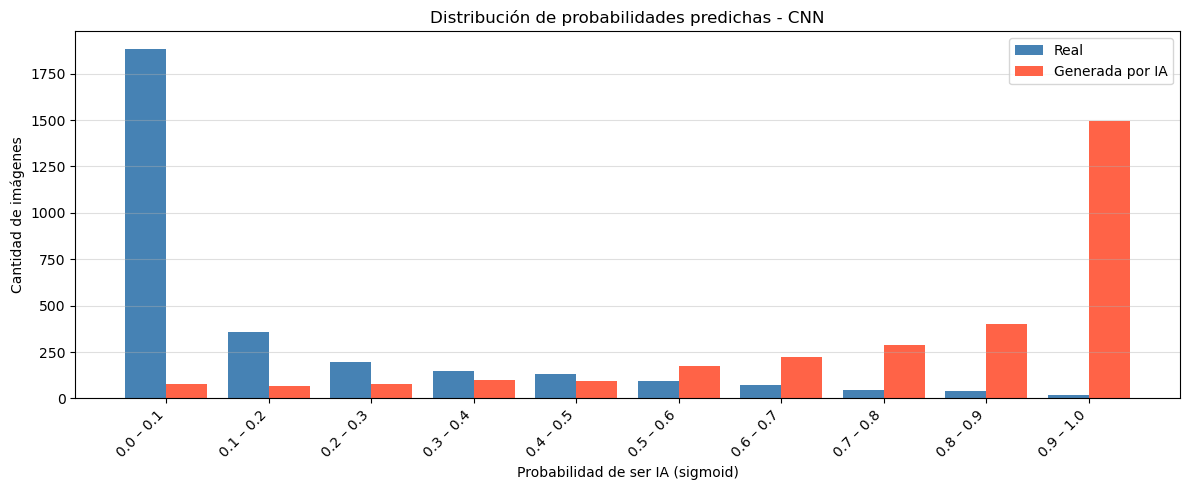

In [36]:
bins = df_probs.index.tolist()
real = df_probs["Real"].values
ia = df_probs["Generada por IA"].values
x = range(len(bins))
width = 0.4

fig, ax = plt.subplots(figsize=(12, 5))
ax.bar([i - width/2 for i in x], real, width=width, label="Real", color="steelblue")
ax.bar([i + width/2 for i in x], ia, width=width, label="Generada por IA", color="tomato")

ax.set_xticks(list(x))
ax.set_xticklabels(bins, rotation=45, ha="right")
ax.set_xlabel("Probabilidad de ser IA (sigmoid)")
ax.set_ylabel("Cantidad de imágenes")
ax.set_title("Distribución de probabilidades predichas - CNN")
ax.legend()
ax.grid(axis="y", alpha=0.4)
plt.tight_layout()
plt.show()

## 3. Transfer Learning - Feature Extraction (ResNet50)

In [37]:
fe_model = build_feature_extractor()
fe_model.load_state_dict(torch.load(OUTPUTS / "fe_best.pt", map_location="cpu"))
fe_model.eval()
print("Feature extraction model cargado.")

Feature extraction model cargado.


In [38]:
test_loader = DataLoader(ImageDataset("test"), batch_size=128, shuffle=False)

all_preds, all_labels = [], []
with torch.no_grad():
    for imgs, labels in test_loader:
        logits = fe_model(imgs)
        preds = (logits.sigmoid() >= 0.5).int().squeeze()
        all_preds.append(preds)
        all_labels.append(labels)

y_pred_fe = torch.cat(all_preds).numpy()
y_true_fe = torch.cat(all_labels).numpy()

In [39]:
print(f"Accuracy:  {accuracy_score(y_true_fe, y_pred_fe):.4f}")
print(f"Precision: {precision_score(y_true_fe, y_pred_fe):.4f}")
print(f"Recall:    {recall_score(y_true_fe, y_pred_fe):.4f}")
print(f"F1:        {f1_score(y_true_fe, y_pred_fe):.4f}")

Accuracy:  0.8808
Precision: 0.8777
Recall:    0.8850
F1:        0.8813


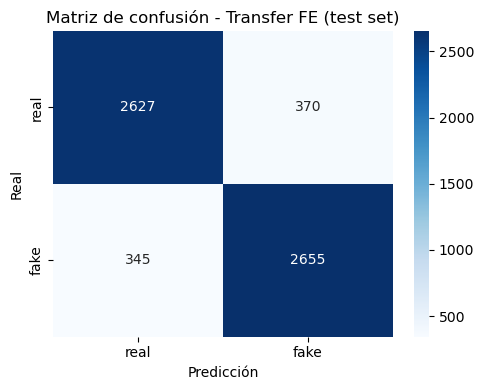

In [40]:
cm_fe = confusion_matrix(y_true_fe, y_pred_fe)

plt.figure(figsize=(5, 4))
sns.heatmap(cm_fe, annot=True, fmt="d", cmap="Blues", xticklabels=["real", "fake"], yticklabels=["real", "fake"])
plt.xlabel("Predicción")
plt.ylabel("Real")
plt.title("Matriz de confusión - Transfer FE (test set)")
plt.tight_layout()
plt.show()

## 4. Transfer Learning - Fine-tuning (ResNet50)

In [41]:
ft_model = build_fine_tuner()
ft_model.load_state_dict(torch.load(OUTPUTS / "ft_best.pt", map_location="cpu"))
ft_model.eval()
print("Fine-tuning model cargado.")

Fine-tuning model cargado.


In [42]:
test_loader = DataLoader(ImageDataset("test"), batch_size=128, shuffle=False)

all_preds, all_labels = [], []
with torch.no_grad():
    for imgs, labels in test_loader:
        logits = ft_model(imgs)
        preds = (logits.sigmoid() >= 0.5).int().squeeze()
        all_preds.append(preds)
        all_labels.append(labels)

y_pred_ft = torch.cat(all_preds).numpy()
y_true_ft = torch.cat(all_labels).numpy()

In [43]:
print(f"Accuracy:  {accuracy_score(y_true_ft, y_pred_ft):.4f}")
print(f"Precision: {precision_score(y_true_ft, y_pred_ft):.4f}")
print(f"Recall:    {recall_score(y_true_ft, y_pred_ft):.4f}")
print(f"F1:        {f1_score(y_true_ft, y_pred_ft):.4f}")

Accuracy:  0.9335
Precision: 0.9257
Recall:    0.9427
F1:        0.9341


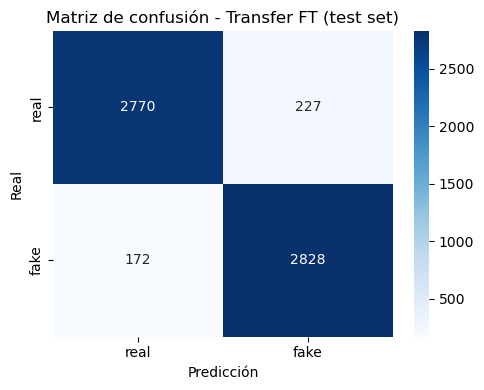

In [44]:
cm_ft = confusion_matrix(y_true_ft, y_pred_ft)

plt.figure(figsize=(5, 4))
sns.heatmap(cm_ft, annot=True, fmt="d", cmap="Blues", xticklabels=["real", "fake"], yticklabels=["real", "fake"])
plt.xlabel("Predicción")
plt.ylabel("Real")
plt.title("Matriz de confusión - Transfer FT (test set)")
plt.tight_layout()
plt.show()

## 5. Comparación de Modelos

In [45]:
resultados = {
    "MLP": (y_true, y_pred),
    "CNN": (y_true_cnn, y_pred_cnn),
    "Transfer FE": (y_true_fe, y_pred_fe),
    "Transfer FT": (y_true_ft, y_pred_ft),
}

filas = []
for nombre, (yt, yp) in resultados.items():
    filas.append({
        "Modelo": nombre,
        "Accuracy": accuracy_score(yt, yp),
        "Precision": precision_score(yt, yp),
        "Recall": recall_score(yt, yp),
        "F1": f1_score(yt, yp),
    })

df_comp = pd.DataFrame(filas).set_index("Modelo")
print(df_comp.to_string(float_format=lambda x: f"{x:.4f}"))

             Accuracy  Precision  Recall     F1
Modelo                                         
MLP            0.7237     0.7017  0.7787 0.7382
CNN            0.8843     0.9037  0.8603 0.8815
Transfer FE    0.8808     0.8777  0.8850 0.8813
Transfer FT    0.9335     0.9257  0.9427 0.9341


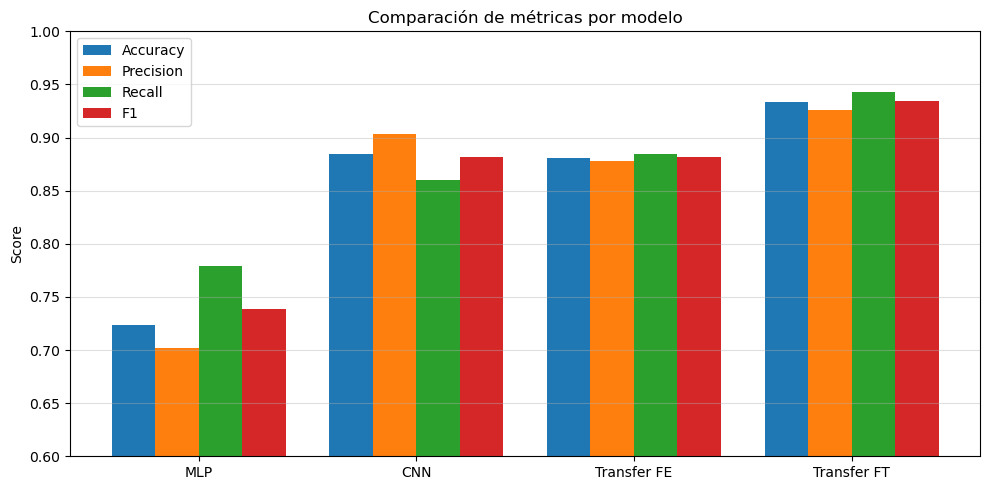

In [46]:
modelos = df_comp.index.tolist()
metricas = ["Accuracy", "Precision", "Recall", "F1"]
x = range(len(modelos))
width = 0.2

fig, ax = plt.subplots(figsize=(10, 5))
for i, metrica in enumerate(metricas):
    ax.bar([xi + i * width for xi in x], df_comp[metrica], width=width, label=metrica)

ax.set_xticks([xi + width * 1.5 for xi in x])
ax.set_xticklabels(modelos)
ax.set_ylim(0.6, 1.0)
ax.set_ylabel("Score")
ax.set_title("Comparación de métricas por modelo")
ax.legend()
ax.grid(axis="y", alpha=0.4)
plt.tight_layout()
plt.show()

## 6. Umbral de Clasificación Óptimo

Por defecto los modelos clasifican como IA toda imagen con probabilidad ≥ 0.5. Ese umbral no necesariamente maximiza las métricas sobre los datos reales.

Usando la **curva ROC** sobre el validation set del mejor modelo (Transfer FT), buscamos el umbral que maximiza el **índice de Youden** (TPR − FPR): el punto de la curva más alejado de la diagonal aleatoria.

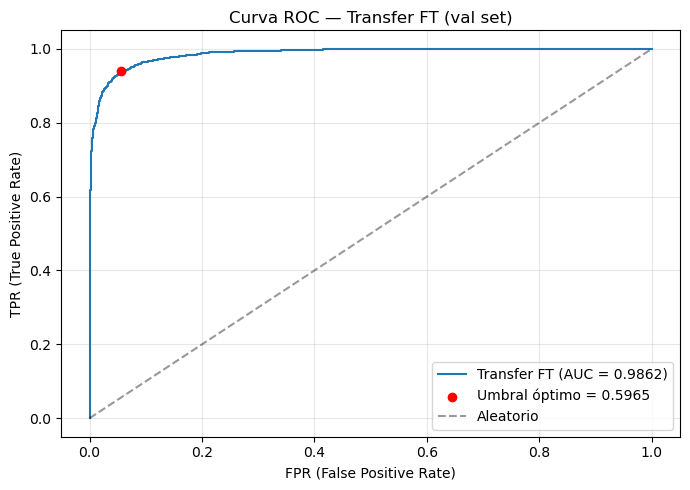

Umbral                          Accuracy  Precision  Recall      F1
-----------------------------------------------------------------
0.5000 (default)                  0.9377     0.9274  0.9497  0.9384
0.5965 (Youden)                   0.9413     0.9434  0.9390  0.9412


In [ ]:
# Probabilidades del Transfer FT sobre val set
val_loader_roc = DataLoader(ImageDataset("val"), batch_size=128, shuffle=False)

all_probs_val, all_labels_val = [], []
ft_model.eval()
with torch.no_grad():
    for imgs, labels in val_loader_roc:
        probs = ft_model(imgs).sigmoid().squeeze()
        all_probs_val.append(probs)
        all_labels_val.append(labels)

probs_val = torch.cat(all_probs_val).numpy()
labels_val = torch.cat(all_labels_val).numpy()

# Curva ROC y umbral óptimo (índice de Youden)
fpr, tpr, thresholds = roc_curve(labels_val, probs_val)
auc = roc_auc_score(labels_val, probs_val)
best_idx = (tpr - fpr).argmax()
best_threshold = thresholds[best_idx]

# Plot
fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(fpr, tpr, label=f"Transfer FT (AUC = {auc:.4f})")
ax.scatter(fpr[best_idx], tpr[best_idx], color="red", zorder=5, label=f"Umbral óptimo = {best_threshold:.4f}")
ax.plot([0, 1], [0, 1], "k--", alpha=0.4, label="Aleatorio")
ax.set_xlabel("FPR (False Positive Rate)")
ax.set_ylabel("TPR (True Positive Rate)")
ax.set_title("Curva ROC — Transfer FT (val set)")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# Métricas con umbral 0.5 vs óptimo
print(f"{'Umbral':<30} {'Accuracy':>9} {'Precision':>10} {'Recall':>7} {'F1':>7}")
print("-" * 65)
for nombre, umbral in [("0.5000 (default)", 0.5), (f"{best_threshold:.4f} (Youden)", best_threshold)]:
    yp = (probs_val >= umbral).astype(int)
    print(f"{nombre:<30} {accuracy_score(labels_val, yp):>9.4f} "
          f"{precision_score(labels_val, yp):>10.4f} "
          f"{recall_score(labels_val, yp):>7.4f} "
          f"{f1_score(labels_val, yp):>7.4f}")

**Conclusión:** El umbral óptimo según el índice de Youden es **0.5965**, levemente por encima del 0.5 por defecto. Esto indica que el modelo tiende a ser algo conservador en sus probabilidades: necesita más confianza para clasificar una imagen como IA generada. Al subir el umbral, la precisión mejora de 0.9274 a 0.9434 (menos falsos positivos) a costa de una leve caída en recall (de 0.9497 a 0.9390). La mejora en F1 es marginal (+0.003), lo que confirma que el umbral de 0.5 ya es una elección razonable para este dataset balanceado.

## 7. Limitación del Modelo: Generalización Fuera de la Distribución

Una limitación importante de este modelo es que **solo generaliza correctamente dentro de la distribución del dataset de entrenamiento**. Las imágenes reales del dataset son paisajes, naturaleza, arquitectura y arte - no retratos ni selfies.

A continuación se muestra una foto real de una persona evaluada por los cuatro modelos:

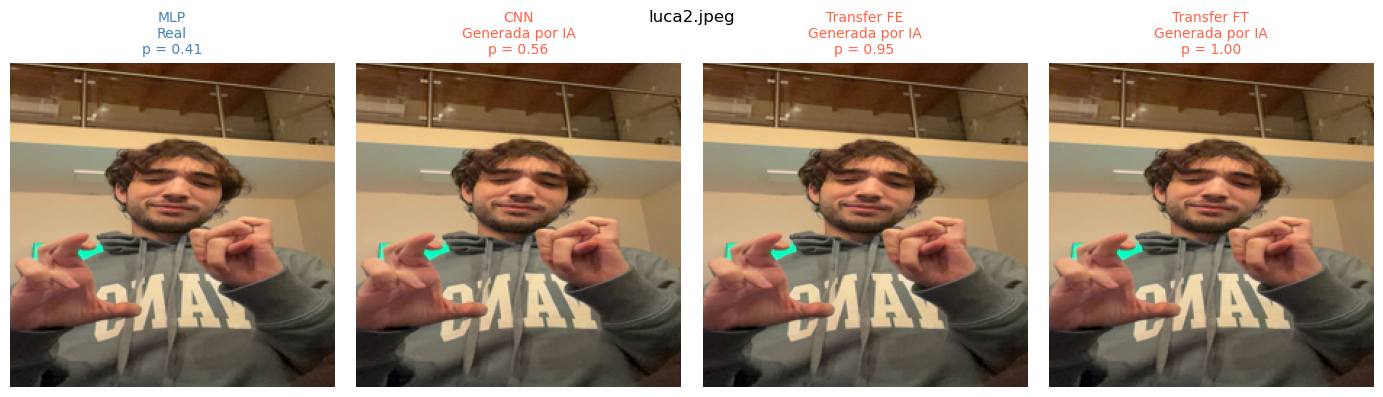

In [48]:
ruta = Path("imgs/luca2.jpeg")

with PILImage.open(ruta) as img:
    img_rgb = img.convert("RGB").resize((IMG_SIZE, IMG_SIZE))

# Preprocesamiento compartido para CNN y Transfer (ya está a 224×224)
x_cnn = get_transforms("val")(img_rgb).unsqueeze(0)

# MLP
img_mlp = img_rgb.resize((MLP_IMG_SIZE, MLP_IMG_SIZE))
x_mlp = pca.transform(np.array(img_mlp, dtype=np.uint8).flatten().reshape(1, -1)).astype(np.float32)
with torch.no_grad():
    prob_mlp = model(torch.from_numpy(x_mlp)).sigmoid().item()

# CNN
with torch.no_grad():
    prob_cnn = cnn_model(x_cnn).sigmoid().item()

# Transfer FE
with torch.no_grad():
    prob_fe = fe_model(x_cnn).sigmoid().item()

# Transfer FT
with torch.no_grad():
    prob_ft = ft_model(x_cnn).sigmoid().item()

# Visualización
nombres = ["MLP", "CNN", "Transfer FE", "Transfer FT"]
probs = [prob_mlp, prob_cnn, prob_fe, prob_ft]

fig, axes = plt.subplots(1, 4, figsize=(14, 4))
for ax, nombre, prob in zip(axes, nombres, probs):
    pred = "Generada por IA" if prob >= 0.5 else "Real"
    color = "tomato" if pred == "Generada por IA" else "steelblue"
    ax.imshow(img_rgb)
    ax.set_title(f"{nombre}\n{pred}\np = {prob:.2f}", color=color, fontsize=10)
    ax.axis("off")

plt.suptitle(ruta.name, fontsize=12)
plt.tight_layout()
plt.show()

### ¿Por qué falla con esta imagen?

Los modelos CNN y Transfer clasifican la foto como generada por IA a pesar de ser real. Esto no es un error del modelo sino una consecuencia directa del dataset:

- Las imágenes **reales** del training set son paisajes, naturaleza, arquitectura y arte — nunca retratos.
- El modelo aprendió a distinguir "imagen original del dataset" vs "versión regenerada por IA de esa imagen", no el concepto general de "foto tomada por un humano".
- Una selfie tomada con un smartphone tiene patrones de textura, ruido y color distintos a los que el modelo aprendió a reconocer como "real".

**El propósito real del modelo** es detectar si una imagen de tipo paisaje, naturaleza o arte fue generada o modificada por IA, comparando la imagen con su distribución de entrenamiento. Dentro de esa distribución, los modelos alcanzan entre 72% y 93% de accuracy en el test set.